# Lab 3: Monte Carlo Methods
## MSDS 684 — Reinforcement Learning
### Morgan Cooper

**Reading:** Sutton & Barto Chapter 5 (Monte Carlo Methods)

**Environment:** Gymnasium's Blackjack-v1

**Goal:** Implement first-visit Monte Carlo control using on-policy MC control with ε-soft policies.

---
## Part 1: Setup & Imports

- Import necessary libraries (gymnasium, numpy, matplotlib, collections, etc.)
- Initialize the Blackjack-v1 environment
- Explore the environment: state space, action space, and how observations are structured
  - State = tuple of (player sum, dealer showing card, usable ace)
  - Actions: 0 = stick, 1 = hit

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from collections import defaultdict
import gymnasium as gym

# Reproducibility
rng = np.random.default_rng(seed=42)

# Initialize environment
env = gym.make("Blackjack-v1", sab=True)

# Explore the environment
print("Action space:", env.action_space)        # Discrete(2): 0=stay, 1=hit
print("Observation space:", env.observation_space)

# Sample a state to see the structure
obs, info = env.reset(seed=42)
print(f"\nSample observation: {obs}")
print(f"  Player sum:          {obs[0]}")
print(f"  Dealer showing card: {obs[1]}")
print(f"  Usable ace:          {obs[2]}")

Action space: Discrete(2)
Observation space: Tuple(Discrete(32), Discrete(11), Discrete(2))

Sample observation: (15, 2, 0)
  Player sum:          15
  Dealer showing card: 2
  Usable ace:          0


---
## Part 2: Episode Generation

- Write a function to generate a complete episode using a given policy
- Use `env.reset()` to start episodes
- Collect (state, action, reward) tuples through `env.step()`
- Continue until the `terminated` flag is True
- Store complete trajectories in Python lists

In [2]:
def generate_episode(env, policy, Q, epsilon, rng_ep):
    """Generate a complete episode using an epsilon-greedy policy.
    
    Args:
        env: Gymnasium environment
        policy: function(state, Q, epsilon, rng) -> action
        Q: action-value dictionary mapping state -> array of Q-values
        epsilon: exploration rate for epsilon-greedy
        rng_ep: numpy random generator
    
    Returns:
        trajectory: list of (state, action, reward) tuples
    """
    trajectory = []
    obs, _ = env.reset()
    done = False
    
    while not done:
        action = policy(obs, Q, epsilon, rng_ep)
        next_obs, reward, terminated, truncated, _ = env.step(action)
        trajectory.append((obs, action, reward))
        done = terminated or truncated
        obs = next_obs
    
    return trajectory


def epsilon_greedy_policy(state, Q, epsilon, rng_p):
    """Epsilon-greedy action selection.
    
    With probability epsilon: choose a random action (explore).
    Otherwise: choose the action with the highest Q-value (exploit).
    """
    if rng_p.random() < epsilon:
        return int(rng_p.integers(2))  # random action: 0 or 1
    return int(np.argmax(Q[state]))


# Test: generate a single episode with a random-ish policy
test_Q = defaultdict(lambda: np.zeros(2))
test_episode = generate_episode(env, epsilon_greedy_policy, test_Q, epsilon=1.0, rng_ep=rng)

print(f"Episode length: {len(test_episode)} steps")
print(f"Trajectory:")
for i, (s, a, r) in enumerate(test_episode):
    action_name = "hit" if a == 1 else "stick"
    print(f"  Step {i}: state={s}, action={action_name}, reward={r}")

Episode length: 1 steps
Trajectory:
  Step 0: state=(13, 10, 0), action=hit, reward=-1.0


---
## Part 3: First-Visit MC Control (On-Policy, ε-Soft)

- Initialize Q(s, a) arbitrarily and returns(s, a) as empty lists
- Initialize an ε-soft policy (equal probability across actions with ε exploration)
- For each episode:
  1. Generate an episode following the current policy
  2. Compute returns by working **backward** through the episode using NumPy
  3. For each **first visit** to a (state, action) pair:
     - Append the return to returns(s, a)
     - Update Q(s, a) = average of returns(s, a)
  4. Update the policy to be ε-greedy with respect to Q
- Train for at least **500,000 episodes**

In [3]:
# Hyperparameters
N_EPISODES = 500_000
EPSILON = 0.1
GAMMA = 1.0  # no discounting for episodic tasks

# Q-table and return tracking
Q = defaultdict(lambda: np.zeros(2))         # state -> [Q(stick), Q(hit)]
returns_sum = defaultdict(lambda: np.zeros(2))   # running sum of returns per (s,a)
returns_count = defaultdict(lambda: np.zeros(2)) # visit count per (s,a)

# Track rewards for learning curves (Part 6)
episode_rewards = []

rng_train = np.random.default_rng(seed=42)

for ep in range(N_EPISODES):
    # Step 1: Generate a complete episode
    trajectory = generate_episode(env, epsilon_greedy_policy, Q, EPSILON, rng_train)
    
    # Record the episode's final reward
    episode_rewards.append(trajectory[-1][2])
    
    # Step 2: Compute returns backward through the episode
    G = 0.0
    visited = set()
    
    for state, action, reward in reversed(trajectory):
        G = reward + GAMMA * G
        
        # Step 3: First-visit check — only update on first occurrence
        if (state, action) not in visited:
            visited.add((state, action))
            returns_sum[state][action] += G
            returns_count[state][action] += 1
            Q[state][action] = returns_sum[state][action] / returns_count[state][action]
    
    # Progress update
    if (ep + 1) % 100_000 == 0:
        recent = episode_rewards[-10_000:]
        win_rate = sum(1 for r in recent if r > 0) / len(recent)
        print(f"Episode {ep+1:>7,} | Recent win rate: {win_rate:.3f}")

print(f"\nTraining complete. States visited: {len(Q)}")

Episode 100,000 | Recent win rate: 0.401
Episode 200,000 | Recent win rate: 0.421
Episode 300,000 | Recent win rate: 0.413
Episode 400,000 | Recent win rate: 0.423
Episode 500,000 | Recent win rate: 0.407

Training complete. States visited: 280


---
## Part 4: Visualization — 3D Value Function Surface Plots

- Derive V(s) from Q(s, a) by taking the max over actions for each state
- Create 3D surface plots using Matplotlib's mplot3d:
  - **Plot 1:** Value function for states **with** a usable ace
  - **Plot 2:** Value function for states **without** a usable ace
  - Axes: player sum vs. dealer showing card vs. state value
- Compare with the value function plots in Sutton & Barto Chapter 5

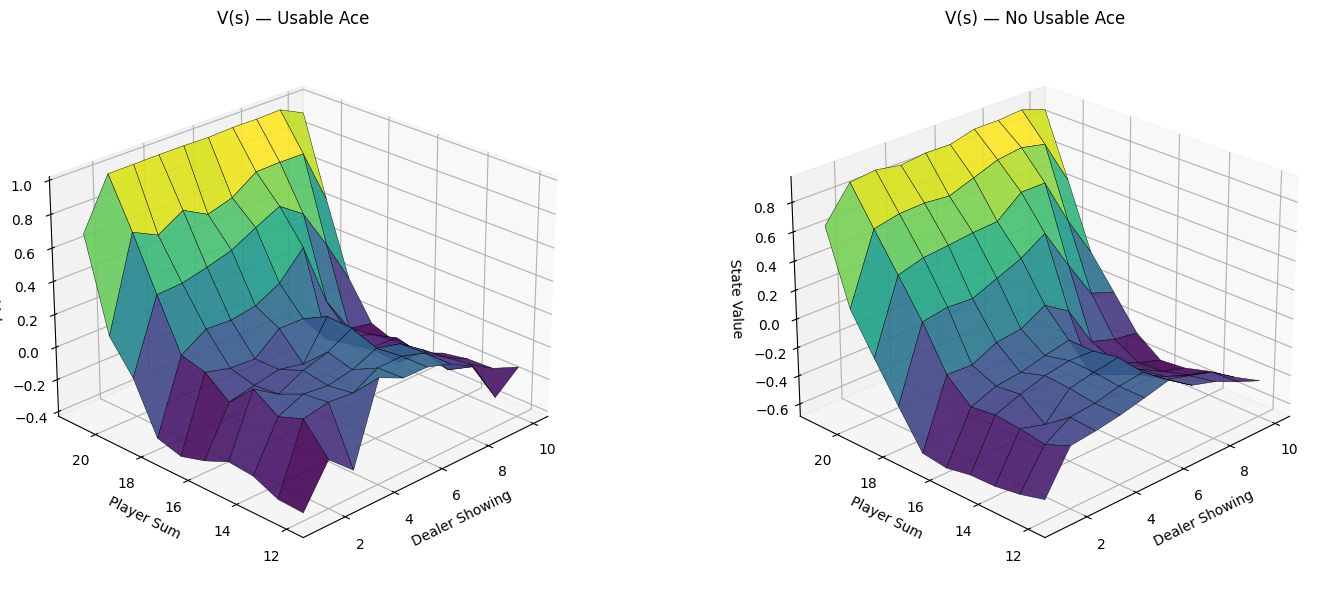

In [4]:
def plot_value_function_3d(Q, title_suffix=""):
    """Create 3D surface plots of the value function for usable and non-usable ace.
    
    V(s) = max_a Q(s, a) for each state.
    """
    # State ranges: player sum 12-21, dealer showing 1-10
    player_range = np.arange(12, 22)
    dealer_range = np.arange(1, 11)
    
    # Create grids for the two ace cases
    X, Y = np.meshgrid(dealer_range, player_range)
    
    # Compute V(s) = max over actions of Q(s, a)
    Z_usable = np.zeros_like(X, dtype=float)
    Z_no_usable = np.zeros_like(X, dtype=float)
    
    for i, player in enumerate(player_range):
        for j, dealer in enumerate(dealer_range):
            state_usable = (player, dealer, True)
            state_no_usable = (player, dealer, False)
            Z_usable[i, j] = np.max(Q[state_usable]) if state_usable in Q else 0.0
            Z_no_usable[i, j] = np.max(Q[state_no_usable]) if state_no_usable in Q else 0.0
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                              subplot_kw={'projection': '3d'})
    
    for ax, Z, ace_label in zip(axes, 
                                 [Z_usable, Z_no_usable],
                                 ["Usable Ace", "No Usable Ace"]):
        ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='black', linewidth=0.3, alpha=0.9)
        ax.set_xlabel("Dealer Showing")
        ax.set_ylabel("Player Sum")
        ax.set_zlabel("State Value")
        ax.set_title(f"V(s) — {ace_label} {title_suffix}")
        ax.view_init(elev=25, azim=-135)
    
    plt.tight_layout()
    plt.show()
    return fig

fig_value = plot_value_function_3d(Q)


---
## Part 5: Visualization — Learned Policy vs. Basic Blackjack Strategy

- Extract the greedy policy from Q (argmax over actions for each state)
- Visualize the learned policy as a heatmap or grid (hit vs. stick decisions)
  - Separate plots for usable ace and no usable ace
- Compare with basic Blackjack strategy (e.g., stand on 20-21, hit below 17, etc.)
- Discuss where the learned policy agrees/disagrees and why

=== Learned Policy ===


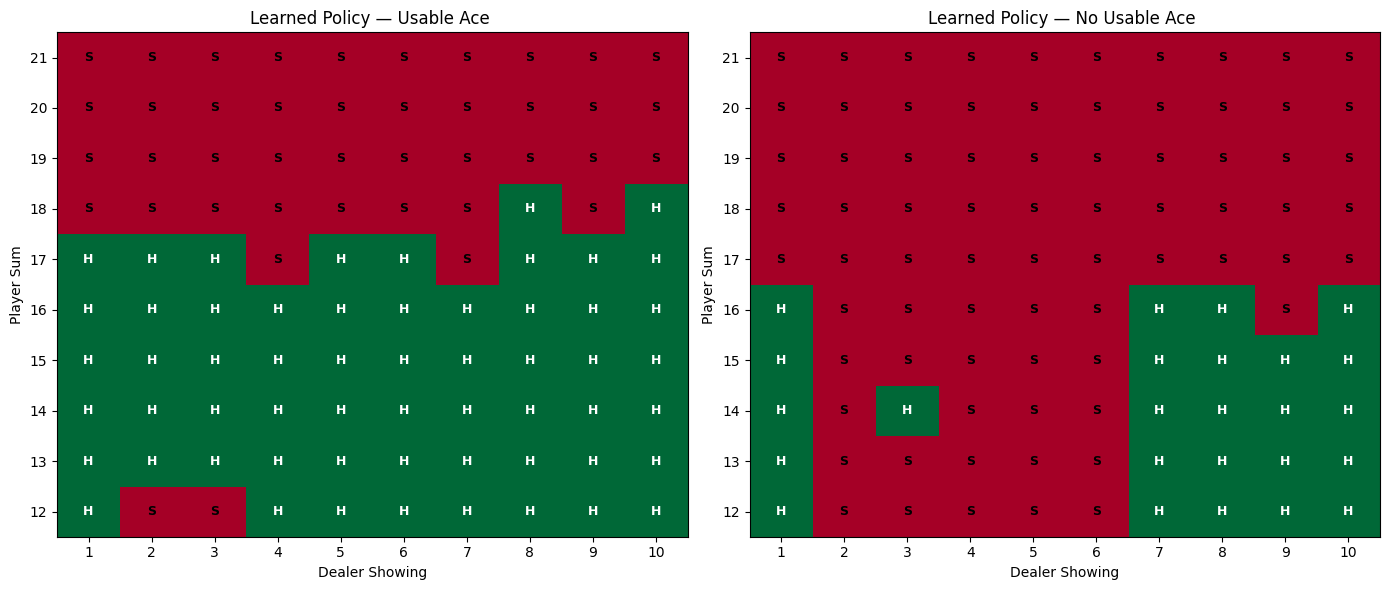


=== Basic Blackjack Strategy (Reference) ===


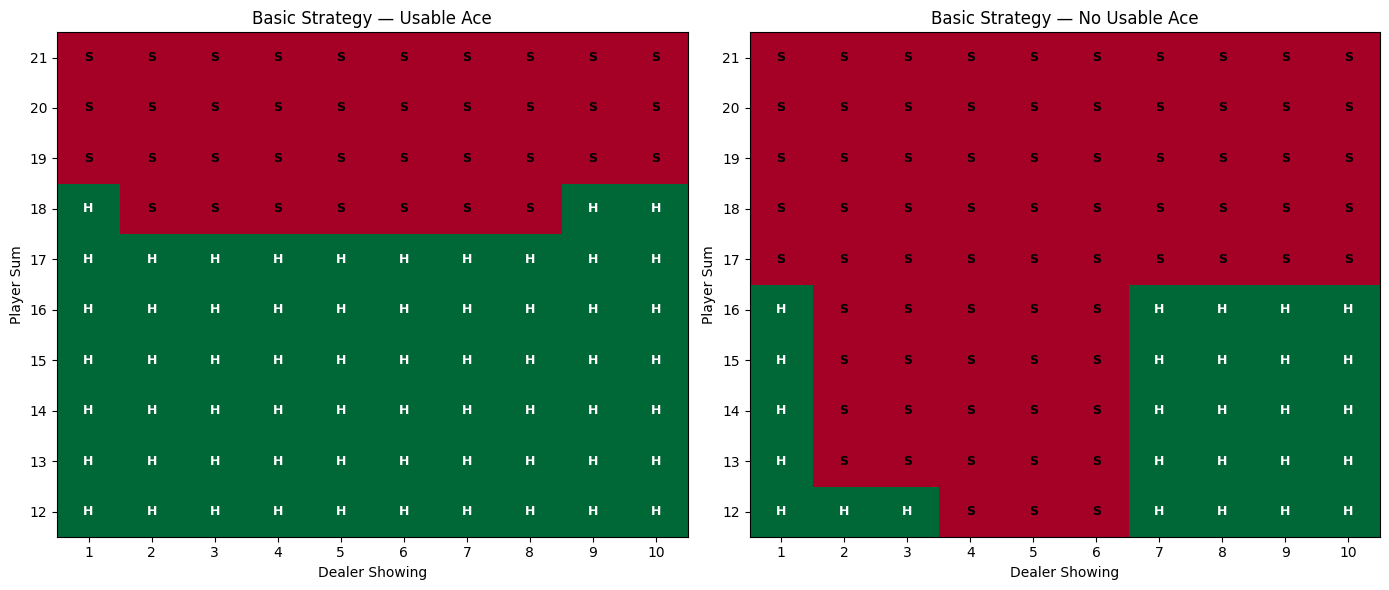

In [5]:
def plot_policy(Q, title_suffix=""):
    """Visualize the learned policy as heatmaps (hit vs stick) for both ace cases."""
    player_range = np.arange(12, 22)
    dealer_range = np.arange(1, 11)
    
    # Extract greedy policy: argmax over actions (0=stick, 1=hit)
    policy_usable = np.zeros((len(player_range), len(dealer_range)), dtype=int)
    policy_no_usable = np.zeros_like(policy_usable)
    
    for i, player in enumerate(player_range):
        for j, dealer in enumerate(dealer_range):
            policy_usable[i, j] = np.argmax(Q[(player, dealer, True)])
            policy_no_usable[i, j] = np.argmax(Q[(player, dealer, False)])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    for ax, policy, ace_label in zip(axes,
                                      [policy_usable, policy_no_usable],
                                      ["Usable Ace", "No Usable Ace"]):
        im = ax.imshow(policy, cmap='RdYlGn', origin='lower', aspect='auto',
                       extent=[0.5, 10.5, 11.5, 21.5], vmin=0, vmax=1)
        ax.set_xlabel("Dealer Showing")
        ax.set_ylabel("Player Sum")
        ax.set_title(f"Learned Policy — {ace_label} {title_suffix}")
        ax.set_xticks(dealer_range)
        ax.set_yticks(player_range)
        
        # Label each cell with H (hit) or S (stick)
        for i, player in enumerate(player_range):
            for j, dealer in enumerate(dealer_range):
                action = policy[i, j]
                label = "H" if action == 1 else "S"
                ax.text(dealer, player, label, ha='center', va='center',
                        fontsize=9, fontweight='bold',
                        color='white' if action == 1 else 'black')
    
    plt.tight_layout()
    plt.show()
    return fig


# Basic Blackjack strategy reference for comparison
def plot_basic_strategy():
    """Show a simplified basic Blackjack strategy for comparison."""
    player_range = np.arange(12, 22)
    dealer_range = np.arange(1, 11)
    
    # Simplified hard totals basic strategy (no usable ace)
    # 0 = stick, 1 = hit
    basic_hard = np.zeros((len(player_range), len(dealer_range)), dtype=int)
    for i, player in enumerate(player_range):
        for j, dealer in enumerate(dealer_range):
            if player >= 17:
                basic_hard[i, j] = 0  # always stick on 17+
            elif player >= 13 and dealer in range(2, 7):
                basic_hard[i, j] = 0  # stick on 13-16 vs weak dealer (2-6)
            elif player == 12 and dealer in range(4, 7):
                basic_hard[i, j] = 0  # stick on 12 vs 4-6
            else:
                basic_hard[i, j] = 1  # hit otherwise
    
    # Simplified soft totals basic strategy (usable ace)
    basic_soft = np.zeros((len(player_range), len(dealer_range)), dtype=int)
    for i, player in enumerate(player_range):
        for j, dealer in enumerate(dealer_range):
            if player >= 20:
                basic_soft[i, j] = 0  # stick on soft 20+
            elif player == 19:
                basic_soft[i, j] = 0  # stick on soft 19
            elif player == 18 and dealer in range(2, 9):
                basic_soft[i, j] = 0  # stick on soft 18 vs 2-8
            else:
                basic_soft[i, j] = 1  # hit otherwise
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    for ax, policy, ace_label in zip(axes,
                                      [basic_soft, basic_hard],
                                      ["Usable Ace", "No Usable Ace"]):
        im = ax.imshow(policy, cmap='RdYlGn', origin='lower', aspect='auto',
                       extent=[0.5, 10.5, 11.5, 21.5], vmin=0, vmax=1)
        ax.set_xlabel("Dealer Showing")
        ax.set_ylabel("Player Sum")
        ax.set_title(f"Basic Strategy — {ace_label}")
        ax.set_xticks(dealer_range)
        ax.set_yticks(player_range)
        
        for i, player in enumerate(player_range):
            for j, dealer in enumerate(dealer_range):
                action = policy[i, j]
                label = "H" if action == 1 else "S"
                ax.text(dealer, player, label, ha='center', va='center',
                        fontsize=9, fontweight='bold',
                        color='white' if action == 1 else 'black')
    
    plt.tight_layout()
    plt.show()
    return fig

print("=== Learned Policy ===")
fig_learned = plot_policy(Q)

print("\n=== Basic Blackjack Strategy (Reference) ===")
fig_basic = plot_basic_strategy()

---
## Part 6: Visualization — Learning Curves

- Track average returns over episodes during training
- Plot learning curves with smoothing (e.g., rolling average)
- Show how the agent's performance improves over time

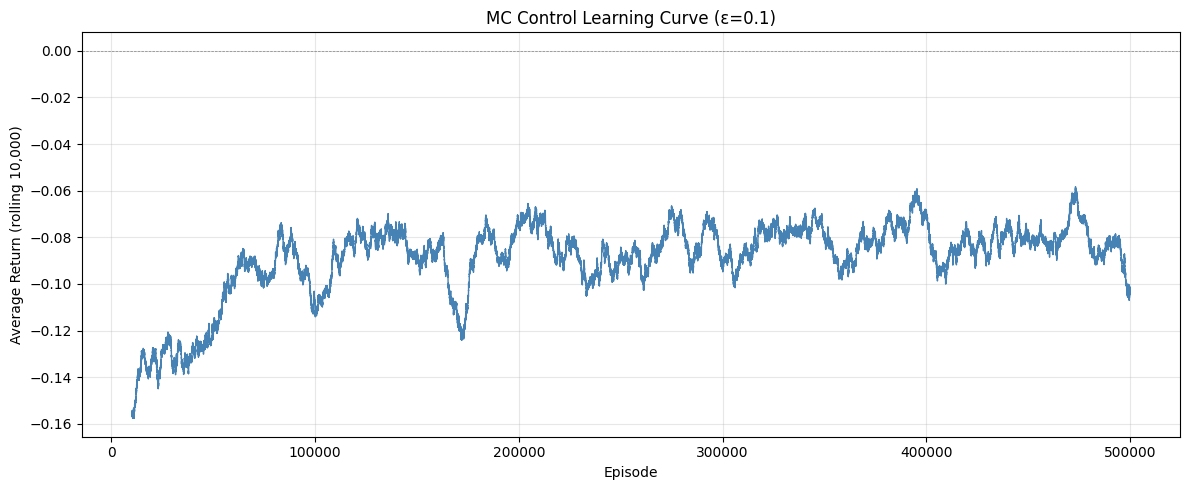

In [6]:
def plot_learning_curve(rewards, window=10_000, title="Learning Curve"):
    """Plot average returns over episodes with rolling average smoothing.
    
    Args:
        rewards: list of per-episode rewards
        window: rolling average window size for smoothing
        title: plot title
    """
    rewards_arr = np.array(rewards, dtype=float)
    
    # Compute rolling average using cumsum trick (fast)
    cumsum = np.cumsum(rewards_arr)
    rolling_avg = (cumsum[window:] - cumsum[:-window]) / window
    
    # X-axis starts at 'window' since we need that many episodes for the first average
    episodes = np.arange(window, len(rewards))
    
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(episodes, rolling_avg, linewidth=1.0, color='steelblue')
    ax.set_xlabel("Episode")
    ax.set_ylabel(f"Average Return (rolling {window:,})")
    ax.set_title(title)
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    return fig

fig_learning = plot_learning_curve(episode_rewards, window=10_000,
                                    title="MC Control Learning Curve (ε=0.1)")

---
## Part 7: Experiment — Different ε Values and Decay Schedules

- Run experiments with different constant ε values (e.g., 0.01, 0.1, 0.3)
- Implement and test ε decay schedules (e.g., linear decay, exponential decay)
- Compare learning curves and final policies across experiments
- Discuss the exploration-exploitation tradeoff in the context of MC methods

Training with constant ε=0.01...
  Done. Final 10k win rate: 0.423
Training with constant ε=0.1...
  Done. Final 10k win rate: 0.419
Training with constant ε=0.3...
  Done. Final 10k win rate: 0.388
Training with Linear Decay (0.3→0.01)...
  Done. Final 10k win rate: 0.434
Training with Exponential Decay (0.3→0.01)...
  Done. Final 10k win rate: 0.423


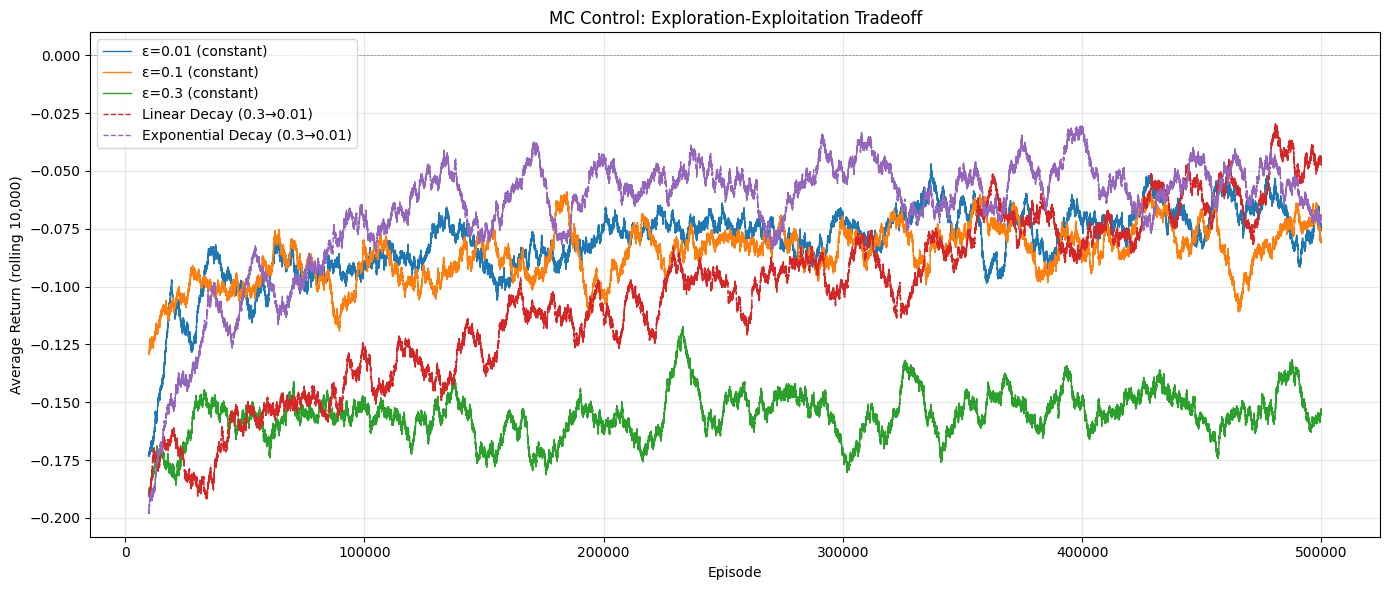

In [7]:
def run_mc_experiment(env, n_episodes, epsilon_schedule, gamma=1.0, seed=42):
    """Run MC control with a given epsilon schedule.
    
    Args:
        env: Gymnasium environment
        n_episodes: number of episodes to train
        epsilon_schedule: either a float (constant) or a function(episode) -> epsilon
        gamma: discount factor
        seed: random seed
    
    Returns:
        Q: learned Q-table
        rewards: list of per-episode rewards
    """
    Q_exp = defaultdict(lambda: np.zeros(2))
    returns_sum_exp = defaultdict(lambda: np.zeros(2))
    returns_count_exp = defaultdict(lambda: np.zeros(2))
    rewards = []
    rng_exp = np.random.default_rng(seed=seed)
    
    for ep in range(n_episodes):
        # Get epsilon for this episode
        eps = epsilon_schedule if isinstance(epsilon_schedule, float) else epsilon_schedule(ep)
        
        # Generate episode
        trajectory = generate_episode(env, epsilon_greedy_policy, Q_exp, eps, rng_exp)
        rewards.append(trajectory[-1][2])
        
        # Backward pass — first-visit MC update
        G = 0.0
        visited = set()
        for state, action, reward in reversed(trajectory):
            G = reward + gamma * G
            if (state, action) not in visited:
                visited.add((state, action))
                returns_sum_exp[state][action] += G
                returns_count_exp[state][action] += 1
                Q_exp[state][action] = returns_sum_exp[state][action] / returns_count_exp[state][action]
    
    return Q_exp, rewards


# --- Experiment 1: Constant epsilon values ---
N_EXP = 500_000
constant_epsilons = [0.01, 0.1, 0.3]
constant_results = {}

for eps in constant_epsilons:
    print(f"Training with constant ε={eps}...")
    Q_exp, rewards_exp = run_mc_experiment(env, N_EXP, eps)
    constant_results[eps] = rewards_exp
    print(f"  Done. Final 10k win rate: {sum(1 for r in rewards_exp[-10_000:] if r > 0) / 10_000:.3f}")

# --- Experiment 2: Decay schedules ---
def linear_decay(ep, start=0.3, end=0.01, total=N_EXP):
    return start - (start - end) * (ep / total)

def exponential_decay(ep, start=0.3, decay_rate=8.0 / 500_000):
    return max(0.01, start * np.exp(-decay_rate * ep))

decay_schedules = {
    "Linear Decay (0.3→0.01)": linear_decay,
    "Exponential Decay (0.3→0.01)": exponential_decay,
}
decay_results = {}

for name, schedule in decay_schedules.items():
    print(f"Training with {name}...")
    Q_exp, rewards_exp = run_mc_experiment(env, N_EXP, schedule)
    decay_results[name] = rewards_exp
    print(f"  Done. Final 10k win rate: {sum(1 for r in rewards_exp[-10_000:] if r > 0) / 10_000:.3f}")

# --- Plot all learning curves together ---
fig, ax = plt.subplots(figsize=(14, 6))
window = 10_000

for eps, rewards in constant_results.items():
    arr = np.array(rewards, dtype=float)
    cumsum = np.cumsum(arr)
    rolling = (cumsum[window:] - cumsum[:-window]) / window
    ax.plot(np.arange(window, len(rewards)), rolling, label=f"ε={eps} (constant)", linewidth=1.0)

for name, rewards in decay_results.items():
    arr = np.array(rewards, dtype=float)
    cumsum = np.cumsum(arr)
    rolling = (cumsum[window:] - cumsum[:-window]) / window
    ax.plot(np.arange(window, len(rewards)), rolling, label=name, linewidth=1.0, linestyle='--')

ax.set_xlabel("Episode")
ax.set_ylabel(f"Average Return (rolling {window:,})")
ax.set_title("MC Control: Exploration-Exploitation Tradeoff")
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
fig_experiment = fig

Training with Linear Decay over 1,500,000 episodes...
  Done. Final 10k win rate: 0.433


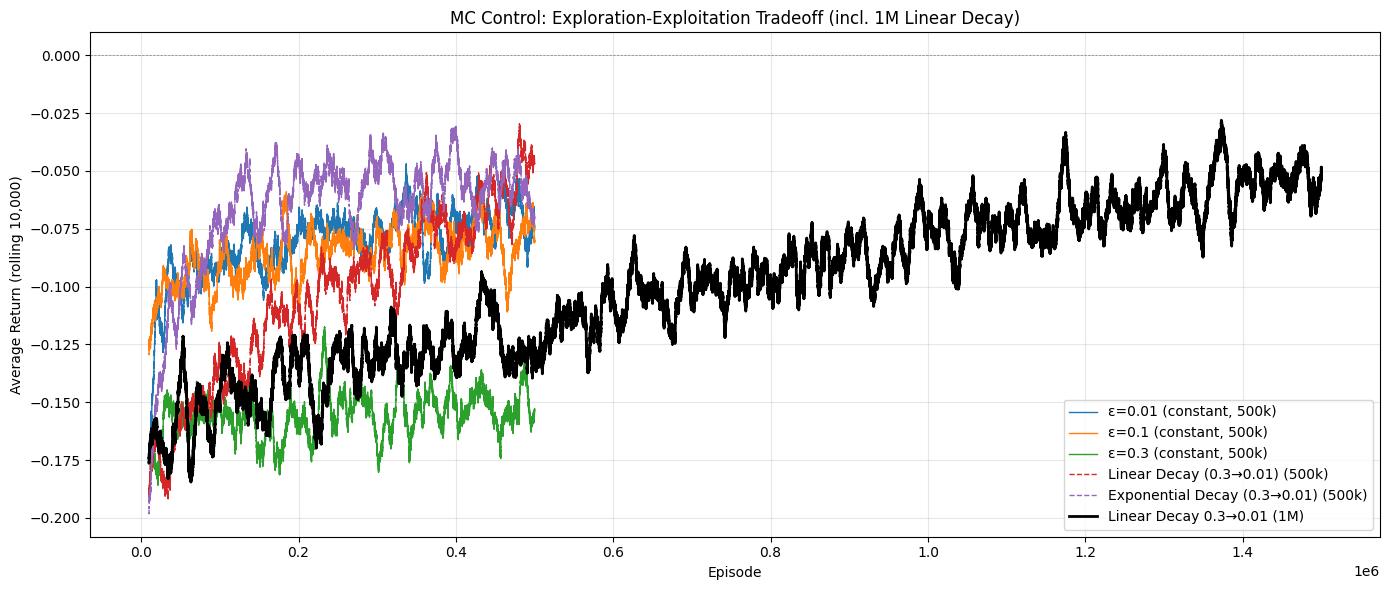

In [8]:
# --- Experiment 3: Linear decay over 1,000,000 episodes ---
N_EXP_LONG = 1_500_000

def linear_decay_long(ep, start=0.3, end=0.01, total=N_EXP_LONG):
    return start - (start - end) * (ep / total)

print(f"Training with Linear Decay over {N_EXP_LONG:,} episodes...")
Q_long, rewards_long = run_mc_experiment(env, N_EXP_LONG, linear_decay_long)
print(f"  Done. Final 10k win rate: {sum(1 for r in rewards_long[-10_000:] if r > 0) / 10_000:.3f}")

# --- Plot comparison: 500k experiments + 1M linear decay ---
fig, ax = plt.subplots(figsize=(14, 6))
window = 10_000

for eps, rewards in constant_results.items():
    arr = np.array(rewards, dtype=float)
    cumsum = np.cumsum(arr)
    rolling = (cumsum[window:] - cumsum[:-window]) / window
    ax.plot(np.arange(window, len(rewards)), rolling, label=f"ε={eps} (constant, 500k)", linewidth=1.0)

for name, rewards in decay_results.items():
    arr = np.array(rewards, dtype=float)
    cumsum = np.cumsum(arr)
    rolling = (cumsum[window:] - cumsum[:-window]) / window
    ax.plot(np.arange(window, len(rewards)), rolling, label=f"{name} (500k)", linewidth=1.0, linestyle='--')

# Add the 1M run
arr = np.array(rewards_long, dtype=float)
cumsum = np.cumsum(arr)
rolling = (cumsum[window:] - cumsum[:-window]) / window
ax.plot(np.arange(window, len(rewards_long)), rolling, 
        label="Linear Decay 0.3→0.01 (1M)", linewidth=2.0, linestyle='-', color='black')

ax.set_xlabel("Episode")
ax.set_ylabel(f"Average Return (rolling {window:,})")
ax.set_title("MC Control: Exploration-Exploitation Tradeoff (incl. 1M Linear Decay)")
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
fig_experiment_long = fig

Training with Linear Decay 0.5→0.001 over 1,000,000 episodes...
  Done. Final 10k win rate: 0.438


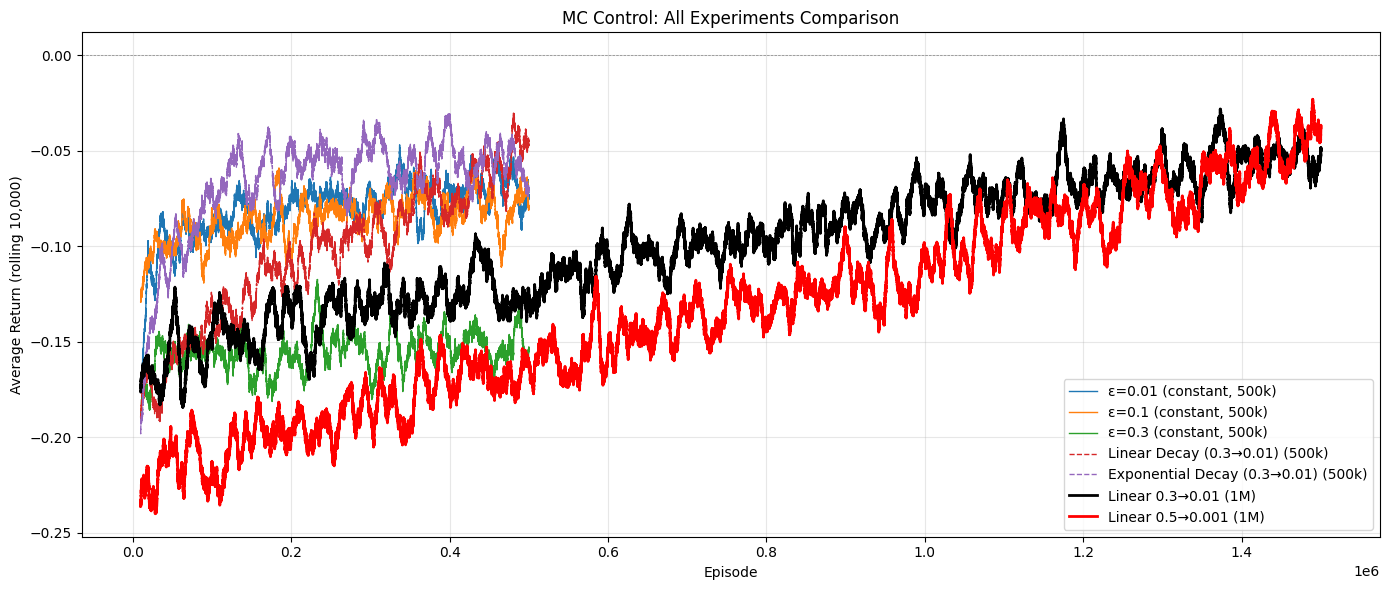

In [9]:
# --- Experiment 4: Aggressive linear decay 0.5 → 0.001 over 1M episodes ---
def linear_decay_aggressive(ep, start=0.5, end=0.001, total=1_500_000):
    return start - (start - end) * (ep / total)

print("Training with Linear Decay 0.5→0.001 over 1,000,000 episodes...")
Q_aggressive, rewards_aggressive = run_mc_experiment(env, 1_500_000, linear_decay_aggressive)
print(f"  Done. Final 10k win rate: {sum(1 for r in rewards_aggressive[-10_000:] if r > 0) / 10_000:.3f}")

# --- Plot all experiments together ---
fig, ax = plt.subplots(figsize=(14, 6))
window = 10_000

for eps, rewards in constant_results.items():
    arr = np.array(rewards, dtype=float)
    cumsum = np.cumsum(arr)
    rolling = (cumsum[window:] - cumsum[:-window]) / window
    ax.plot(np.arange(window, len(rewards)), rolling, label=f"ε={eps} (constant, 500k)", linewidth=1.0)

for name, rewards in decay_results.items():
    arr = np.array(rewards, dtype=float)
    cumsum = np.cumsum(arr)
    rolling = (cumsum[window:] - cumsum[:-window]) / window
    ax.plot(np.arange(window, len(rewards)), rolling, label=f"{name} (500k)", linewidth=1.0, linestyle='--')

# 1M linear decay 0.3 → 0.01
arr = np.array(rewards_long, dtype=float)
cumsum = np.cumsum(arr)
rolling = (cumsum[window:] - cumsum[:-window]) / window
ax.plot(np.arange(window, len(rewards_long)), rolling,
        label="Linear 0.3→0.01 (1M)", linewidth=2.0, color='black')

# 1M linear decay 0.5 → 0.001
arr = np.array(rewards_aggressive, dtype=float)
cumsum = np.cumsum(arr)
rolling = (cumsum[window:] - cumsum[:-window]) / window
ax.plot(np.arange(window, len(rewards_aggressive)), rolling,
        label="Linear 0.5→0.001 (1M)", linewidth=2.0, linestyle='-', color='red')

ax.set_xlabel("Episode")
ax.set_ylabel(f"Average Return (rolling {window:,})")
ax.set_title("MC Control: All Experiments Comparison")
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
fig_experiment_aggressive = fig

---
## Part 8: Save Figures

- Save all key visualizations to the `figures/` directory as PNG files
- Update the figure paths in `generate_report.py`
- Run `generate_report.py` to produce the final PDF

In [10]:
import os
os.makedirs("figures", exist_ok=True)

# Save all key figures
fig_value.savefig("figures/value_function_3d.png", dpi=150, bbox_inches='tight')
fig_learned.savefig("figures/learned_policy.png", dpi=150, bbox_inches='tight')
fig_basic.savefig("figures/basic_strategy.png", dpi=150, bbox_inches='tight')
fig_learning.savefig("figures/learning_curve.png", dpi=150, bbox_inches='tight')
fig_experiment.savefig("figures/epsilon_comparison_500k.png", dpi=150, bbox_inches='tight')
fig_experiment_long.savefig("figures/epsilon_comparison_1M.png", dpi=150, bbox_inches='tight')
fig_experiment_aggressive.savefig("figures/epsilon_comparison_all.png", dpi=150, bbox_inches='tight')

print("Figures saved:")
for f in sorted(os.listdir("figures")):
    print(f"  figures/{f}")

Figures saved:
  figures/basic_strategy.png
  figures/epsilon_comparison_1M.png
  figures/epsilon_comparison_500k.png
  figures/epsilon_comparison_all.png
  figures/learned_policy.png
  figures/learning_curve.png
  figures/value_function_3d.png
